In [1]:
import datetime as dt
import numpy as np
import json
import pandas as pd
import matplotlib.pyplot as plt
import os

In [2]:


# Load the JSON file
with open('labels25.json', 'r') as f:
    data = json.load(f)

# List to hold all interval records
records = []

# Iterate over tasks (each item in the top-level list)
for task in data:
    task_id = task.get('id')
    # Each task may have multiple annotations
    for ann in task.get('annotations', []):
        annotation_id = ann.get('id')
        for result in ann.get('result', []):
            value = result.get('value', {})
            start = value.get('start')
            end = value.get('end')
            labels = value.get('timeserieslabels', [])
            # Use first label or join if multiple
            label = labels[0] if labels else None
            
            records.append({
                'task_id': task_id,
                'annotation_id': annotation_id,
                'start': start,
                'end': end,
                'label': label,
                # Optionally include result id and origin
                'result_id': result.get('id'),
                'origin': result.get('origin')
            })

# Create DataFrame
df = pd.DataFrame(records)

# Convert start and end to datetime if desired
df['start'] = pd.to_datetime(df['start'])
df['end'] = pd.to_datetime(df['end'])

# Display
print(df.head())
print(f"\nTotal intervals extracted: {len(df)}")

   task_id  annotation_id               start                 end   label  \
0       11              3 2024-12-19 13:44:00 2024-12-19 14:23:00  Normal   
1       11              3 2024-12-19 14:23:00 2024-12-19 15:01:00  Normal   
2       11              3 2024-12-19 15:02:00 2024-12-19 15:25:00  Normal   
3       11              3 2024-12-19 15:23:00 2024-12-19 16:29:00  Normal   
4       11              3 2024-12-19 17:01:00 2024-12-19 17:47:00  Normal   

    result_id  origin  
0  irYs7O2wue  manual  
1  35pajYqKQH  manual  
2  KRD4UMq2o0  manual  
3  OUBnZgCB-h  manual  
4  HfRiMjDdUF  manual  

Total intervals extracted: 283


In [8]:
df

,task_id,annotation_id,start,end,label,result_id,origin
0,11,3,2024-12-19 13:44:00,2024-12-19 14:23:00,Normal,irYs7O2wue,manual
1,11,3,2024-12-19 14:23:00,2024-12-19 15:01:00,Normal,35pajYqKQH,manual
2,11,3,2024-12-19 15:02:00,2024-12-19 15:25:00,Normal,KRD4UMq2o0,manual
3,11,3,2024-12-19 15:23:00,2024-12-19 16:29:00,Normal,OUBnZgCB-h,manual
4,11,3,2024-12-19 17:01:00,2024-12-19 17:47:00,Normal,HfRiMjDdUF,manual
...,...,...,...,...,...,...,...
278,12,4,2026-01-01 17:36:00,2026-01-01 18:44:00,Normal,vGpNt3UomB,manual
279,12,4,2026-01-03 17:21:00,2026-01-03 18:04:00,Normal,rXOuWUJyYa,manual
280,12,4,2025-09-18 15:37:00,2025-09-18 16:04:00,Normal,FRuEFHzjZk,manual
281,12,4,2025-12-30 17:56:00,2025-12-30 18:10:00,Normal,DynVKYKhi5,manual


In [9]:
delta_tflare = (df["end"] - df["start"])#.dt.seconds
# delta_tflare_min =  
delta_tflare = delta_tflare.dt.total_seconds()/60

In [6]:
%matplotlib inline

In [10]:
plt.style.library

{'seaborn-v0_8-white': RcParams({'axes.axisbelow': True,
           'axes.edgecolor': '.15',
           'axes.facecolor': 'white',
           'axes.grid': False,
           'axes.labelcolor': '.15',
           'axes.linewidth': 1.25,
           'figure.facecolor': 'white',
           'font.family': ['sans-serif'],
           'font.sans-serif': ['Arial',
                               'Liberation Sans',
                               'DejaVu Sans',
                               'Bitstream Vera Sans',
                               'sans-serif'],
           'grid.color': '.8',
           'grid.linestyle': '-',
           'image.cmap': 'Greys',
           'legend.frameon': False,
           'legend.numpoints': 1,
           'legend.scatterpoints': 1,
           'lines.solid_capstyle': <CapStyle.round: 'round'>,
           'text.color': '.15',
           'xtick.color': '.15',
           'xtick.direction': 'out',
           'xtick.major.size': 0.0,
           'xtick.minor.size': 0.0,
     

In [11]:
plt.style.use('seaborn-v0_8-paper')
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.dpi': 100
})

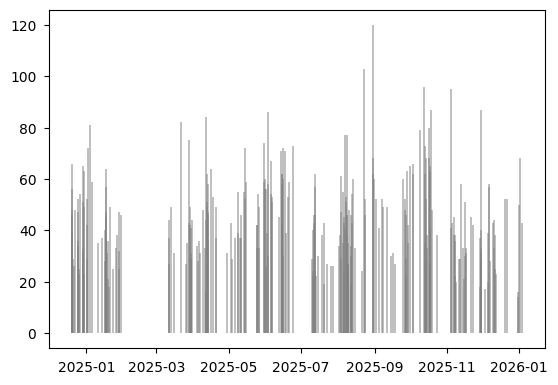

In [12]:
fig = plt.figure()
plt.plot(df["start"], delta_tflare, marker="x", lw=0, color="k")
plt.vlines(df["start"],0,  delta_tflare, color="gray", alpha=0.5)
# plt.steam(df["start"], delta_tflare)

<>:8: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:8: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
/tmp/ipykernel_1108883/3641602383.py:8: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
  plt.xlabel('$\Delta t_{flare}$ (m)', fontsize=12)


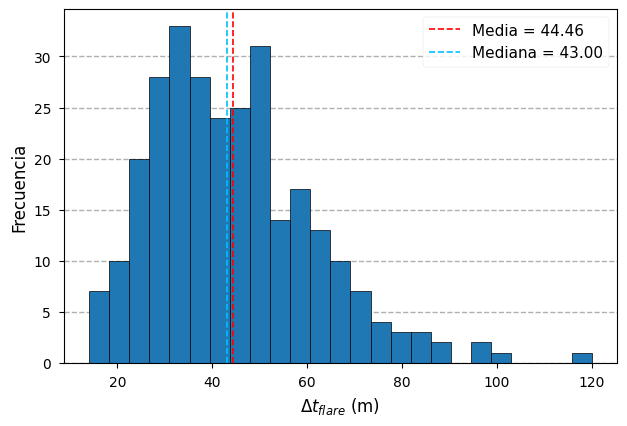

In [13]:
fig = plt.figure()#figsize=(4,3))
n, bins, patches = plt.hist(delta_tflare,bins=25, lw=0.5, edgecolor="k")
mean_val = np.mean(delta_tflare)
median_val = np.median(delta_tflare)
ax = plt.gca()
plt.axvline(mean_val, color='red', linestyle='--', linewidth=1.2, label=f'Media = {mean_val:.2f}')
plt.axvline(median_val, color='deepskyblue', linestyle='--', linewidth=1.2, label=f'Mediana = {median_val:.2f}')
plt.xlabel('$\Delta t_{flare}$ (m)', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
# plt.title('distr', fontsize=14, fontweight='bold')
plt.grid(False)
plt.grid(axis="y", lw=1, ls="--")
ax.set_axisbelow(True) 
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

In [11]:
plt.close("all")

In [18]:
# start_hour = df["start"].time.hour/
start_timeh = df["start"].dt.hour + df["start"].dt.minute/60 + df["start"].dt.second/3600

In [21]:
total_labeled_flares = len(start_timeh)
print("TOTAL SOLAR FLARES IN TRAIN = ", total_labeled_flares)

TOTAL SOLAR FLARES IN TRAIN =  283


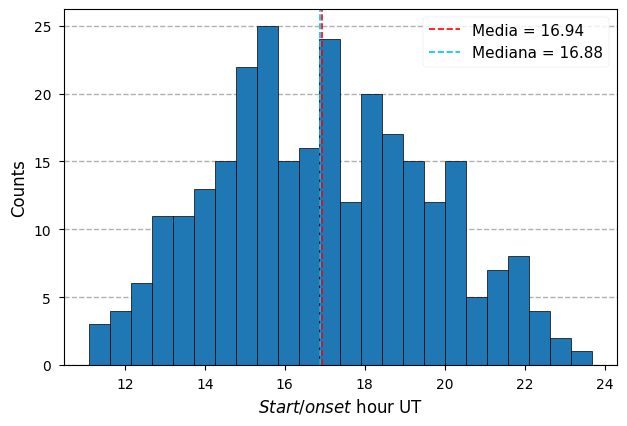

In [20]:
n, bins, patches = plt.hist(start_timeh,bins=24, lw=0.5, edgecolor="k")
mean_val = np.mean(start_timeh)
median_val = np.median(start_timeh)
ax = plt.gca()
plt.axvline(mean_val, color='red', linestyle='--', linewidth=1.2, label=f'Media = {mean_val:.2f}')
plt.axvline(median_val, color='deepskyblue', linestyle='--', linewidth=1.2, label=f'Mediana = {median_val:.2f}')
plt.xlabel('$Start/onset$ hour UT', fontsize=12)
plt.ylabel('Counts', fontsize=12)
# plt.title('distr', fontsize=14, fontweight='bold')
plt.grid(False)
plt.grid(axis="y", lw=1, ls="--")
ax.set_axisbelow(True) 
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

In [23]:
print(len(n), len(bins))
print(n) 
print(
    bins)

24 25
[ 3.  4.  6. 11. 11. 13. 15. 22. 25. 15. 16. 24. 12. 20. 17. 15. 12. 15.
  5.  7.  8.  4.  2.  1.]
[11.1        11.62430556 12.14861111 12.67291667 13.19722222 13.72152778
 14.24583333 14.77013889 15.29444444 15.81875    16.34305556 16.86736111
 17.39166667 17.91597222 18.44027778 18.96458333 19.48888889 20.01319444
 20.5375     21.06180556 21.58611111 22.11041667 22.63472222 23.15902778
 23.68333333]


In [154]:
datadf = pd.DataFrame()
for i in [1,2]:
    _df = pd.read_csv(f"PIU_amp_dB_NAA_1min_2025_p{i}.csv", parse_dates=True, index_col=0)
    datadf = pd.concat((datadf, _df))
    

In [155]:
datadf["state"] = np.zeros(len(datadf))
datadf.head()

,NAA,GOES18,state
DateTime,,,
2024-12-17 16:13:00,-28.845532,0.000002,0.0
2024-12-17 16:14:00,3.439003,0.000002,0.0
2024-12-17 16:15:00,3.441335,0.000002,0.0
2024-12-17 16:16:00,3.438579,0.000002,0.0
2024-12-17 16:17:00,3.430763,0.000002,0.0


In [61]:
del xr, sw


In [2]:
import sys
sys.path.append("/home/diace/pavnet-v3/vlfcode/")
from sxrf_download import sunpy_xrf as xr
import swlaspdata as sw

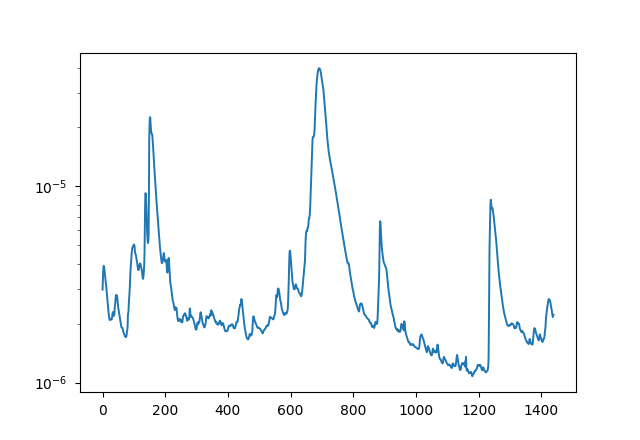

In [29]:
sw.goes_satellite=18
sw.datasets["xray_flux_template"] = "dap/noaa_goes_xrs_1m_template"
# sw.datasets["xray_flux_template"] = "noaa_goes_xrs_1m_template"
df = sw.get_data("dap/noaa_goes19_xrs_1m", "2025-08-07","2025-08-08")
fig = plt.figure()
ax = plt.subplot()
df["longwave (W/m^2)"].plot()
ax.set_yscale("log")
plt.show()

In [30]:
datadf.index[0], datadf.index[-1]

(Timestamp('2024-12-17 16:13:00'), Timestamp('2026-01-06 04:59:00'))

In [34]:
ss1 = (dt.datetime(2024,12,17)-dt.datetime(2000,1,1))
ss2= (dt.datetime(2026,1,1)-dt.datetime(2000,1,1))
ss1*24*3600,ss2*24*3600

(datetime.timedelta(days=787708800), datetime.timedelta(days=820540800))

In [49]:
# datadf = pd.concat([datadf, goes19], axis=1)
datadf.head()

,NAA,GOES18,state,GOES19
DateTime,,,,
2024-12-17 16:13:00,-28.845532,0.000002,0.0,None
2024-12-17 16:14:00,3.439003,0.000002,0.0,None
2024-12-17 16:15:00,3.441335,0.000002,0.0,None
2024-12-17 16:16:00,3.438579,0.000002,0.0,None
2024-12-17 16:17:00,3.430763,0.000002,0.0,None


In [156]:
# download data from the GOEs 19 
goes19 = sw.get_data("dap/noaa_goes19_xrs_1m", "2024-12-17","2026-01-06")
t_ = [dt.datetime(2000,1,1,12) + dt.timedelta(seconds=i) 
      for i in goes19["time (seconds since 2000-01-01 12:00:00)"]]
goes19.index = t_

In [146]:
goes19.head()

,time (seconds since 2000-01-01 12:00:00),shortwave (W/m^2),longwave (W/m^2),shortwave_flag,longwave_flag,shortwave_masked (W/m^2),longwave_masked (W/m^2)
2024-12-17 00:00:00,787665600.0,4.738311e-08,0.000002,0,0,4.738311e-08,0.000002
2024-12-17 00:01:00,787665660.0,4.870723e-08,0.000002,0,0,4.870723e-08,0.000002
2024-12-17 00:02:00,787665720.0,4.626812e-08,0.000002,0,0,4.626812e-08,0.000002
2024-12-17 00:03:00,787665780.0,4.503747e-08,0.000002,0,0,4.503747e-08,0.000002
2024-12-17 00:04:00,787665840.0,4.152613e-08,0.000002,0,0,4.152613e-08,0.000002


In [157]:
print("datadf has duplicates:", datadf.index.has_duplicates)
print("goes19 has duplicates:", goes19.index.has_duplicates)

datadf has duplicates: True
goes19 has duplicates: False


In [159]:
# datadf.drop(c|olumns =["GOES19"])
datadf = datadf[~datadf.index.duplicated(keep='first')]
goes19 = goes19[~goes19.index.duplicated(keep='first')]

# Now concatenate
datadf = pd.concat((datadf, goes19["longwave (W/m^2)"]), axis=1)

/tmp/ipykernel_22988/2454294909.py:6: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  datadf = pd.concat((datadf, goes19["longwave (W/m^2)"]), axis=1)


In [160]:
%matplotlib inline
datadf.rename(columns={"longwave (W/m^2)": 'GOES19'}, inplace=True)
datadf

,NAA,GOES18,state,GOES19
2024-12-17 00:00:00,NaN,NaN,NaN,0.000002
2024-12-17 00:01:00,NaN,NaN,NaN,0.000002
2024-12-17 00:02:00,NaN,NaN,NaN,0.000002
2024-12-17 00:03:00,NaN,NaN,NaN,0.000002
2024-12-17 00:04:00,NaN,NaN,NaN,0.000002
...,...,...,...,...
2026-01-06 04:55:00,1.252027,0.000002,0.0,NaN
2026-01-06 04:56:00,1.171363,0.000001,0.0,NaN
2026-01-06 04:57:00,1.106434,0.000001,0.0,NaN
2026-01-06 04:58:00,1.198408,0.000001,0.0,NaN


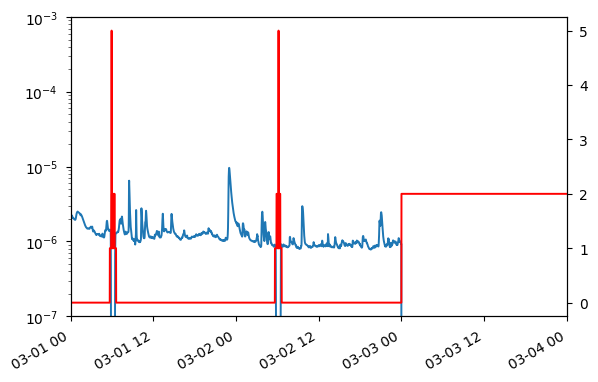

In [165]:
fig = plt.figure()
ax = plt.subplot()
plt.plot(datadf["GOES19"])

plt.ylim(1e-7, 1e-3)
plt.yscale("log")
ax2 = ax.twinx()
ax2.plot(goes19["longwave_flag"], color="r")
ax2.set_xlim(dt.datetime(2025, 3,1), dt.datetime(2025, 3,4))
fig.autofmt_xdate()

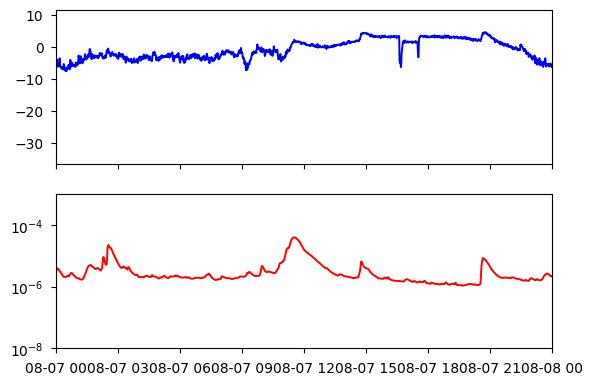

In [72]:
# datadf["GOES19"].shape , goes19.shape
fig, (ax1,ax2)= plt.subplots(2, sharex=True)
ax1.plot(datadf["NAA"], color="blue")
ax2.plot(datadf["longwave (W/m^2)"], color="red")
plt.xlim(dt.datetime(2025,8,7), dt.datetime(2025,8,8))
ax2.set_ylim(1e-8, 1e-3)
ax2.set_yscale("log")
plt.show()

In [167]:
# vamos a etiquetar estados en una columna del df de los datos de amplitud y xrays (datadf)
# vamos rango 	time (seconds since 2000-01-01 12:00:00) tras rango del df de etiquetas (df)
fig = plt.figure()
peakdf = pd.DataFrame() 	

#k=0
for k, (r0, rf) in enumerate(df.loc[:, ["start", "end"]].values):
    #print(r0,rf)
    _wdf = datadf.loc[r0:rf, ["NAA", "GOES19"]]
    try:
        # x ray flux
        ii_vlf = _wdf["NAA"].argmax()
        df.loc[k, "middle"] = _wdf["NAA"].index[ii_vlf] # change point between onset and decay
        peak_amp = _wdf["NAA"].iloc[ii_vlf]  # grab the window within the time labeled
        peak_time = _wdf.index[ii_vlf]
        peakdf.loc[k, ["amp_peak_time", "peak_amp"]] = [peak_time, peak_amp]
        
        # amplitude / vlf signal
        ii = _wdf["GOES19"].argmax()
        peak_flux = _wdf["GOES19"].iloc[ii]  # grab the window within the time labeled
        peak_time = _wdf.index[ii]
        peakdf.loc[k, ["flux_peak_time", "peak_flux"]] = [peak_time, peak_flux]
    except Exception as e:
        print(k, peak_time)
        print(e)
    # peakdf.loc[peak_time, "peak_amp"] = peak_amp
    # print(y)
    # plt.plot(y)
    # _wdf.plot(marker="o")
    # break

<Figure size 640x440 with 0 Axes>

In [168]:
df

,task_id,annotation_id,start,end,label,result_id,origin,middle
0,11,3,2024-12-19 13:44:00,2024-12-19 14:23:00,Normal,irYs7O2wue,manual,2024-12-19 14:00:00
1,11,3,2024-12-19 14:23:00,2024-12-19 15:01:00,Normal,35pajYqKQH,manual,2024-12-19 14:36:00
2,11,3,2024-12-19 15:02:00,2024-12-19 15:25:00,Normal,KRD4UMq2o0,manual,2024-12-19 15:08:00
3,11,3,2024-12-19 15:23:00,2024-12-19 16:29:00,Normal,OUBnZgCB-h,manual,2024-12-19 15:36:00
4,11,3,2024-12-19 17:01:00,2024-12-19 17:47:00,Normal,HfRiMjDdUF,manual,2024-12-19 17:18:00
...,...,...,...,...,...,...,...,...
278,12,4,2026-01-01 17:36:00,2026-01-01 18:44:00,Normal,vGpNt3UomB,manual,2026-01-01 17:59:00
279,12,4,2026-01-03 17:21:00,2026-01-03 18:04:00,Normal,rXOuWUJyYa,manual,2026-01-03 17:30:00
280,12,4,2025-09-18 15:37:00,2025-09-18 16:04:00,Normal,FRuEFHzjZk,manual,2025-09-18 15:46:00
281,12,4,2025-12-30 17:56:00,2025-12-30 18:10:00,Normal,DynVKYKhi5,manual,2025-12-30 18:00:00


In [106]:
peakdf = peakdf.sort_index()
peakdf_clean = peakdf[peakdf["peak_flux"]>-1]
print(peakdf)


          amp_peak_time  peak_amp      flux_peak_time  peak_flux
0   2024-12-19 14:00:00  3.334560 2024-12-19 13:52:00   0.000007
1   2024-12-19 14:36:00  4.850425 2024-12-19 14:32:00   0.000008
2   2024-12-19 15:08:00  4.556116 2024-12-19 15:07:00   0.000006
3   2024-12-19 15:36:00  8.523838 2024-12-19 15:34:00   0.000038
4   2024-12-19 17:18:00  5.180168 2024-12-19 17:16:00   0.000006
..                  ...       ...                 ...        ...
278 2026-01-01 17:59:00  4.700521 2026-01-01 17:59:00   0.000006
279 2026-01-03 17:30:00  5.280421 2026-01-03 17:29:00   0.000008
280 2025-09-18 15:46:00  4.846098 2025-09-18 15:41:00   0.000004
281 2025-12-30 18:00:00  3.783848 2025-12-30 18:03:00   0.000004
282 2025-12-30 15:56:00  3.914998 2025-12-30 15:55:00   0.000005

[283 rows x 4 columns]


Text(0.5, 0, 'Xray Flux at Peak')

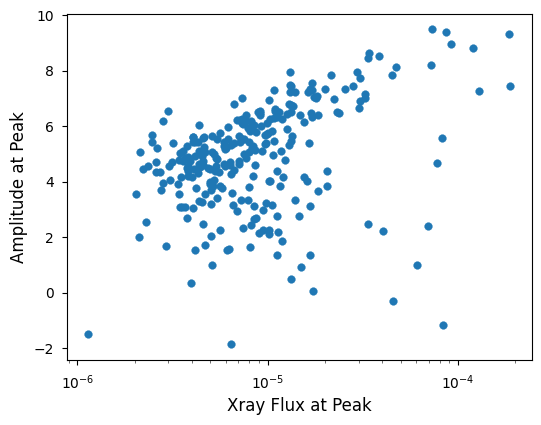

In [114]:
ifg = plt.figure(figsize=(6, 4.5))
ax= plt.subplot()
plt.scatter(peakdf_clean["peak_flux"].values, peakdf_clean["peak_amp"].values,)# lw=0, markeredgecolor="darkred", markerfacecolor="none")
# plt.plot(peakdf["peak_flux"])
ax.set_xscale("log")
ax.set_ylabel("Amplitude at Peak")
ax.set_xlabel("Xray Flux at Peak")

In [171]:
datadf.loc[:, "state"] = 0 #np.zeros(len())
for k, (ti, tm, tf) in enumerate(df.loc[:,["start", "middle", "end"]].values):
    datadf.loc[ti:tm, "state"] = 1 # onset state (from start till peak)
    datadf.loc[tm:tf, "state"] = 2 # onset state (from middle (peak) till end (return to normal))
    

In [181]:
%matplotlib inline

In [184]:
datadf.to_csv("vlf_trainingdata_2025_piu.csv", index=True)

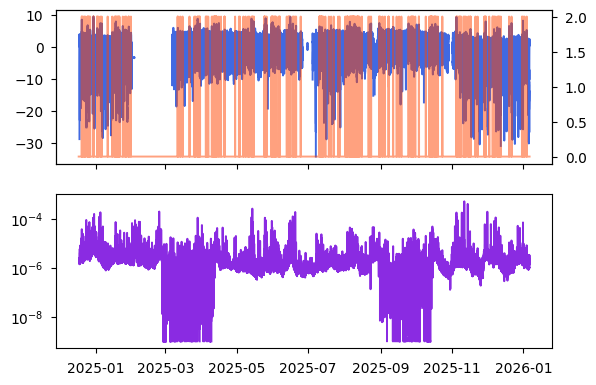

In [183]:
fig, axs = plt.subplots(2, sharex=True)
axs[0].plot(datadf["NAA"], color="royalblue") #.plot(ax=axs[0])
_ax = axs[0].twinx()
_ax.step(datadf.index, datadf["state"], color="orangered", alpha=0.5)
axs[1].plot(datadf["GOES18"], color="blueviolet")#.plot(color="r",ax=axs[1])
axs[1].set_yscale("log")
plt.show()

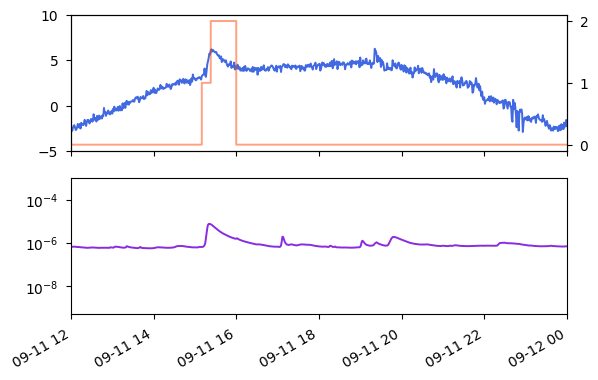

In [195]:
fig, axs = plt.subplots(2, sharex=True)
axs[0].plot(datadf["NAA"], color="royalblue") #.plot(ax=axs[0])
axs[0].set_ylim(-5,10)
_ax = axs[0].twinx()
_ax.step(datadf.index, datadf["state"], color="orangered", alpha=0.5)
axs[1].plot(datadf["GOES18"], color="blueviolet")#.plot(color="r",ax=axs[1])
axs[1].set_yscale("log")
_ax.set_xlim(dt.datetime(2025, 9,11,12), dt.datetime(2025, 9,12))
fig.autofmt_xdate()
plt.show()

### Distribution by energy/flare type

<>:5: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:6: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:7: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:5: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:6: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:7: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
/tmp/ipykernel_122254/1026951725.py:5: SyntaxWarning: "\l" is an invalid escape se

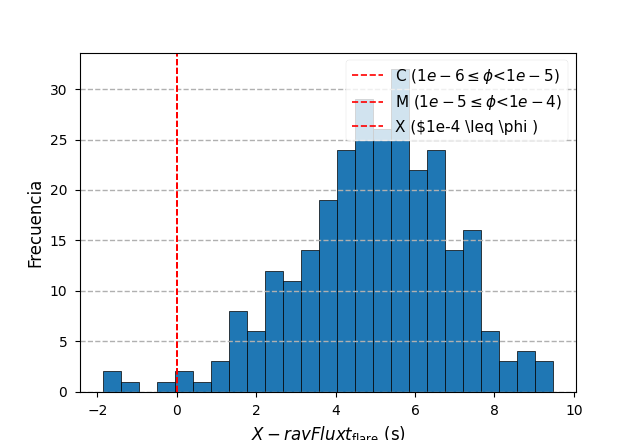

In [31]:
fig = plt.figure()#figsize=(4,3)) 	time (seconds since 2000-01-01 12:00:00)
n, bins, patches = plt.hist(peakdf.values,bins=25, lw=0.5, edgecolor="k")
mean_val = np.mean(peakdf.values)
median_val = np.median(peakdf.values)
plt.axvline(1e-6, color='red', linestyle='--', linewidth=1.2, label=f'C ($1e-6 \leq \phi \less 1e-5 $)')
plt.axvline(1e-5, color='red', linestyle='--', linewidth=1.2, label=f'M ($1e-5 \leq \phi \less 1e-4 $)')
plt.axvline(1e-4, color='red', linestyle='--', linewidth=1.2, label=f'X ($1e-4 \leq \phi )')
# plt.axvline(1e-5, color='deepskyblue', linestyle='--', linewidth=1.2, label=f'Mediana = {median_val:.2f}')
plt.xlabel(r'$X-ray Flux t_{\mathrm{flare}}$ (s)', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
# plt.title('distr', fontsize=14, fontweight='bold')
plt.grid(False)
plt.grid(axis="y", lw=1, ls="--")
plt.legend(fontsize=11)

<Axes: >

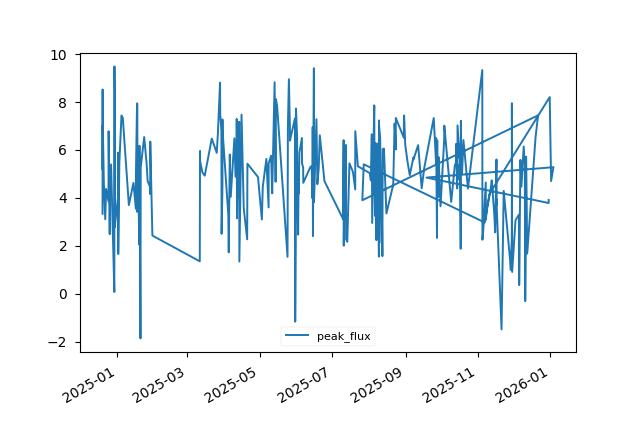

In [32]:
peakdf.plot()

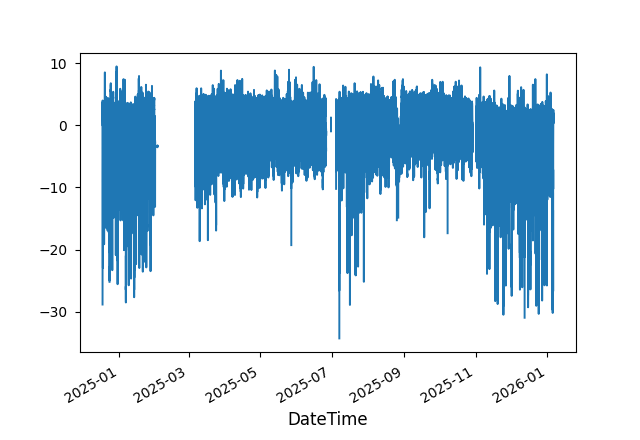

In [24]:
fig, ax = plt.subplots()
datadf["NAA"].plot(ax=ax)
plt.show()

In [53]:
df.loc[:, ["start", "end"]].values

array([['2024-12-19T13:44:00.000000', '2024-12-19T14:23:00.000000'],
       ['2024-12-19T14:23:00.000000', '2024-12-19T15:01:00.000000'],
       ['2024-12-19T15:02:00.000000', '2024-12-19T15:25:00.000000'],
       ['2024-12-19T15:23:00.000000', '2024-12-19T16:29:00.000000'],
       ['2024-12-19T17:01:00.000000', '2024-12-19T17:47:00.000000'],
       ['2024-12-19T17:47:00.000000', '2024-12-19T18:43:00.000000'],
       ['2024-12-19T18:54:00.000000', '2024-12-19T19:42:00.000000'],
       ['2024-12-20T16:43:00.000000', '2024-12-20T17:12:00.000000'],
       ['2024-12-21T20:30:00.000000', '2024-12-21T20:56:00.000000'],
       ['2024-12-22T14:01:00.000000', '2024-12-22T14:49:00.000000'],
       ['2024-12-24T14:02:00.000000', '2024-12-24T14:38:00.000000'],
       ['2024-12-24T15:07:00.000000', '2024-12-24T15:54:00.000000'],
       ['2024-12-24T16:27:00.000000', '2024-12-24T17:19:00.000000'],
       ['2024-12-24T18:17:00.000000', '2024-12-24T18:51:00.000000'],
       ['2024-12-25T15:06:00.00000

### test data

In [7]:
#files = ["/data/vlf/PIU/data/"]
r = "/data/vlf/PIU/data/"
files = [os.path.join(r, x) for x in os.listdir(r) if x.startswith("ANTAR")]
files

['/data/vlf/PIU/data/ANTAR_AMPLITUDE_2026-01-06-to-2026-02-01.csv',
 '/data/vlf/PIU/data/ANTAR_AMPLITUDE_2026-04-01-to-2026-04-08.csv',
 '/data/vlf/PIU/data/ANTAR_AMPLITUDE_2026-02-01-to-2026-03-01.csv',
 '/data/vlf/PIU/data/ANTAR_AMPLITUDE_2026-03-03-to-2026-04-01.csv']

In [9]:
testdf = pd.DataFrame()
for f in files:
    _df = pd.read_csv(f, parse_dates=True, index_col=0)
    testdf = pd.concat((testdf, _df))

testdf = testdf.sort_index()
testdf

,NPM,NAA,NLK,NLM,NAU,NPM-filt,NAA-filt,NLK-filt,NLM-filt,NAU-filt
2026-01-06 05:00:07,3.203410,1.084304,1.132410,1.135385,2.280181e-06,3.203410,1.084304,1.132410,1.135385,2.280181e-06
2026-01-06 05:00:17,3.006778,1.018855,1.131634,1.134155,3.063910e-06,3.167326,1.095861,1.125022,1.124720,2.703181e-06
2026-01-06 05:00:27,3.198742,1.090411,1.048174,1.037071,3.108185e-06,3.137835,1.105742,1.119848,1.116816,3.087220e-06
2026-01-06 05:00:36,3.203319,1.145672,1.159984,1.166493,2.749095e-06,3.119635,1.112833,1.118580,1.113763,3.403500e-06
2026-01-06 05:00:46,3.211128,1.100257,1.047577,1.044662,2.977108e-06,3.114186,1.116946,1.122001,1.116482,3.640542e-06
...,...,...,...,...,...,...,...,...,...,...
2026-04-08 04:59:03,1.159459,0.201362,0.980911,0.977269,8.490061e-07,1.170989,0.280184,1.016064,1.017419,1.533435e-06
2026-04-08 04:59:13,1.125279,0.202849,1.014875,1.015485,1.083762e-06,1.161910,0.271618,1.030051,1.031503,1.405367e-06
2026-04-08 04:59:22,1.146341,0.237563,0.923467,0.913599,1.569076e-06,1.148479,0.267118,1.043540,1.045256,1.236745e-06
2026-04-08 04:59:32,1.260778,0.273809,1.033369,1.036540,1.496972e-06,1.131866,0.266815,1.055827,1.057973,1.039316e-06


In [10]:
testdf = testdf["NAA"].resample("1min").mean()

(29505600.0, 29508480.0)

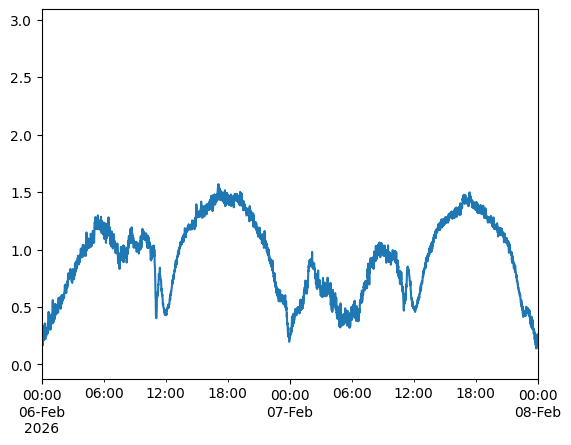

In [14]:
fig, ax = plt.subplots()
testdf.plot(ax=ax)
ax.set_xlim(dt.datetime(2026,2,6), dt.datetime(2026,2,8))